In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATA_PATH = "train_set_80_percent.csv"

df = pd.read_csv(DATA_PATH)

print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())

Original shape: (1586, 20)
Columns: ['id', 'rank', 'year', 'player', 'batted_ball_events', 'launch_angle', 'sweet_spot_percentage', 'max_ev', 'average_ev', 'fly_ball_line_drive_ev', 'ground_ball_ev', 'max_distance', 'average_distance', 'average_homerun', 'hard_hit_95mph+', 'hard_hit_percentage', 'hard_hit_swing_percentage', 'total_barrels', 'barrels_batted_balls_percentage', 'barrels_plate_appearance_percentage']


In [ ]:
df = df.drop(columns=["id", "rank", "player"])
print("\nShape after dropping id, rank, player:", df.shape)


Shape after dropping id, rank, player: (1586, 17)


In [ ]:
print("\nData types:")
print(df.dtypes)


Data types:
year                                     int64
batted_ball_events                       int64
launch_angle                           float64
sweet_spot_percentage                  float64
max_ev                                 float64
average_ev                             float64
fly_ball_line_drive_ev                 float64
ground_ball_ev                         float64
max_distance                             int64
average_distance                         int64
average_homerun                        float64
hard_hit_95mph+                          int64
hard_hit_percentage                    float64
hard_hit_swing_percentage              float64
total_barrels                            int64
barrels_batted_balls_percentage        float64
barrels_plate_appearance_percentage    float64
dtype: object


In [ ]:
print("\nBasic .info():")
df.info()


Basic .info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1586 entries, 0 to 1585
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   year                                 1586 non-null   int64  
 1   batted_ball_events                   1586 non-null   int64  
 2   launch_angle                         1586 non-null   float64
 3   sweet_spot_percentage                1586 non-null   float64
 4   max_ev                               1586 non-null   float64
 5   average_ev                           1586 non-null   float64
 6   fly_ball_line_drive_ev               1586 non-null   float64
 7   ground_ball_ev                       1586 non-null   float64
 8   max_distance                         1586 non-null   int64  
 9   average_distance                     1586 non-null   int64  
 10  average_homerun                      1577 non-null   float64
 11  hard_hit_95mph

In [ ]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,year,batted_ball_events,launch_angle,sweet_spot_percentage,max_ev,average_ev,fly_ball_line_drive_ev,ground_ball_ev,max_distance,average_distance,average_homerun,hard_hit_95mph+,hard_hit_percentage,hard_hit_swing_percentage,total_barrels,barrels_batted_balls_percentage,barrels_plate_appearance_percentage
0,2020,107,9.5,35.5,106.1,89.0,90.6,89.5,394,156,392.0,45,42.1,19.1,2,1.9,1.4
1,2020,164,8.7,32.3,113.4,95.9,100.2,91.6,458,175,410.0,102,62.2,22.0,32,19.5,12.5
2,2020,95,13.0,34.7,110.3,91.7,95.0,89.5,425,171,387.0,49,51.6,16.4,9,9.5,6.4
3,2022,230,18.4,36.5,113.4,88.7,92.8,85.9,428,181,391.0,90,39.1,11.9,26,11.3,6.9
4,2016,293,8.3,32.4,105.1,85.1,88.9,82.1,408,159,400.0,51,17.4,7.4,9,3.1,2.2


In [ ]:
print("\nMissing values per column:")
missing = df.isna().sum().sort_values(ascending=False)
print(missing)


Missing values per column:
average_homerun                        9
year                                   0
batted_ball_events                     0
sweet_spot_percentage                  0
launch_angle                           0
average_ev                             0
fly_ball_line_drive_ev                 0
ground_ball_ev                         0
max_ev                                 0
max_distance                           0
average_distance                       0
hard_hit_95mph+                        0
hard_hit_percentage                    0
hard_hit_swing_percentage              0
total_barrels                          0
barrels_batted_balls_percentage        0
barrels_plate_appearance_percentage    0
dtype: int64


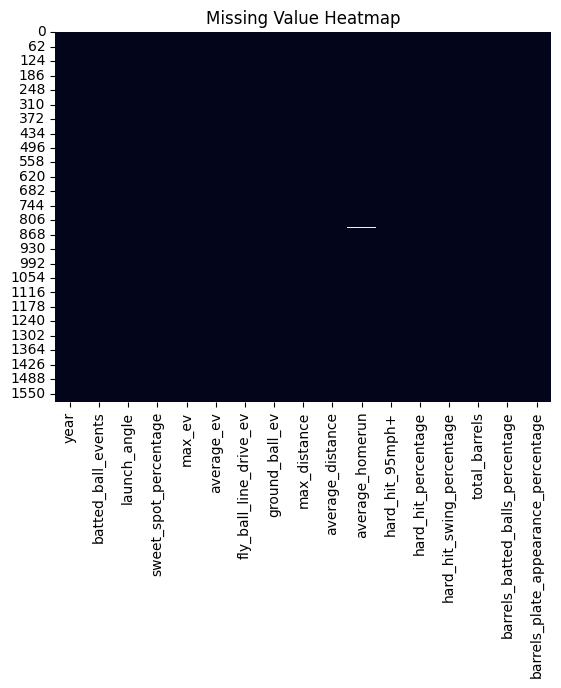

In [ ]:
if missing.max() > 0:
    plt.figure()
    sns.heatmap(df.isna(), cbar=False)
    plt.title("Missing Value Heatmap")
    plt.show()
else:
    print("\nNo missing values detected.")

In [ ]:
print("\nDescriptive statistics (numeric columns):")
desc = df.describe().T
display(desc)


Descriptive statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
year,1586.0,2018.496847,2.280141,2015.0,2017.00,2018.00,2020.000,2022.0
batted_ball_events,1586.0,329.451450,113.671653,67.0,257.00,333.00,416.000,599.0
launch_angle,1586.0,12.484489,4.605644,-7.9,9.40,12.50,15.500,26.8
sweet_spot_percentage,1586.0,33.565637,4.095650,18.5,30.80,33.60,36.200,49.2
max_ev,1586.0,110.782724,3.206176,99.9,108.60,110.70,112.900,122.2
average_ev,1586.0,88.800820,2.213362,80.5,87.30,88.90,90.200,96.0
fly_ball_line_drive_ev,1586.0,92.835309,2.644554,83.0,91.20,93.00,94.500,101.3
ground_ball_ev,1586.0,85.901765,2.610551,73.9,84.10,85.90,87.675,94.1
max_distance,1586.0,435.924968,20.122465,359.0,423.00,436.00,449.000,505.0
average_distance,1586.0,171.261034,20.123498,98.0,158.00,172.00,186.000,234.0


In [ ]:
target_col = "hard_hit_percentage"

print(f"\nTarget: {target_col}")
print(df[target_col].describe())


Target: hard_hit_percentage
count    1586.000000
mean       37.587011
std         7.984116
min         7.300000
25%        32.800000
50%        38.250000
75%        42.700000
max        62.200000
Name: hard_hit_percentage, dtype: float64


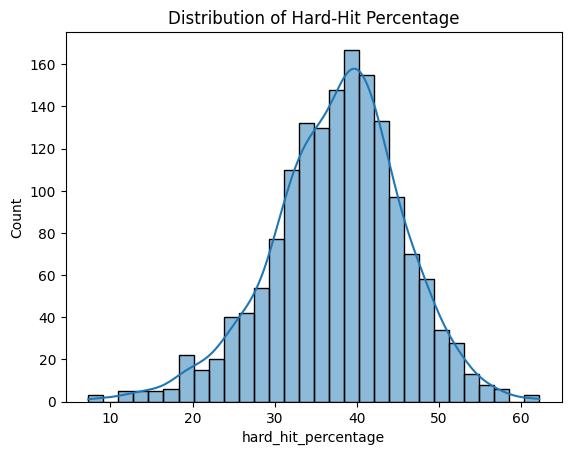

In [ ]:
plt.figure()
sns.histplot(df[target_col], kde=True, bins=30)
plt.title("Distribution of Hard-Hit Percentage")
plt.xlabel("hard_hit_percentage")
plt.ylabel("Count")
plt.show()

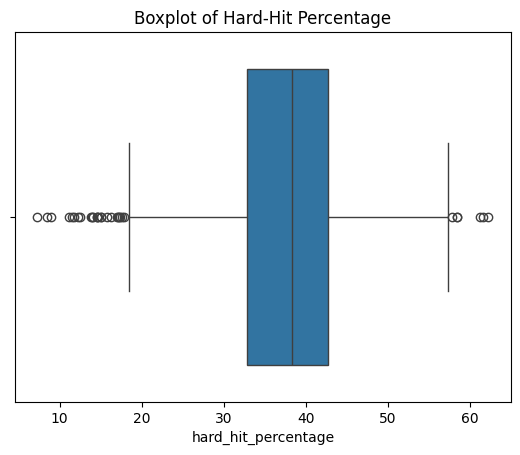

In [ ]:
plt.figure()
sns.boxplot(x=df[target_col])
plt.title("Boxplot of Hard-Hit Percentage")
plt.xlabel("hard_hit_percentage")
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", numeric_cols)


Numeric columns: ['year', 'batted_ball_events', 'launch_angle', 'sweet_spot_percentage', 'max_ev', 'average_ev', 'fly_ball_line_drive_ev', 'ground_ball_ev', 'max_distance', 'average_distance', 'average_homerun', 'hard_hit_95mph+', 'hard_hit_percentage', 'hard_hit_swing_percentage', 'total_barrels', 'barrels_batted_balls_percentage', 'barrels_plate_appearance_percentage']


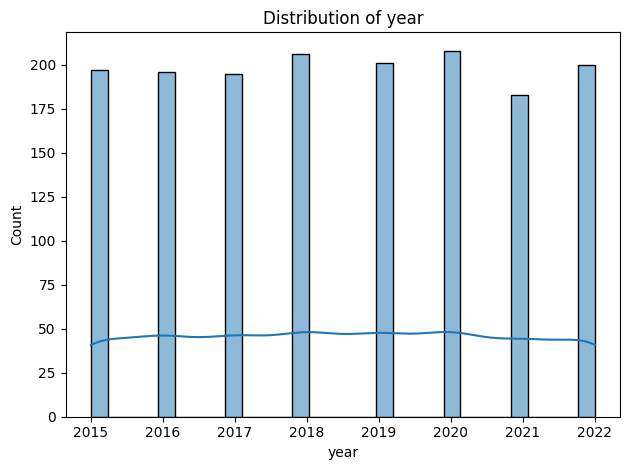

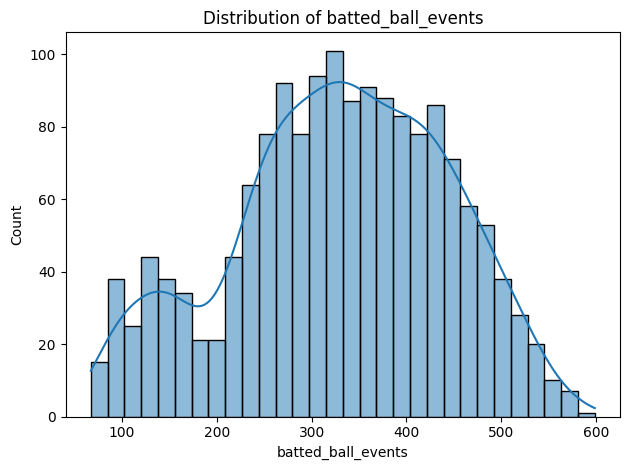

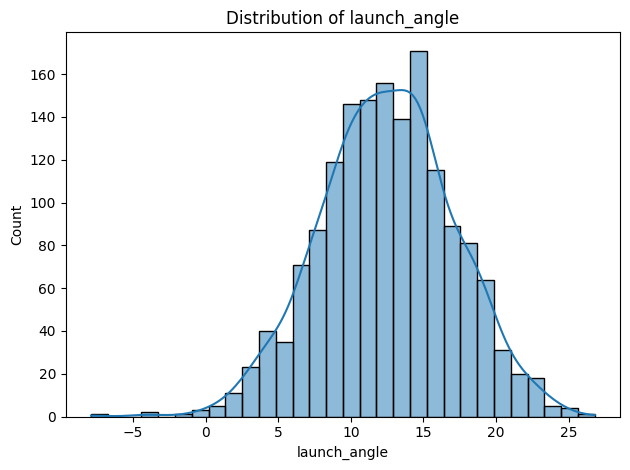

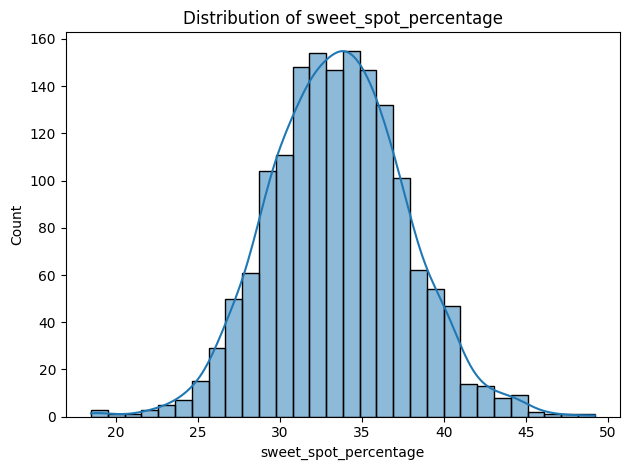

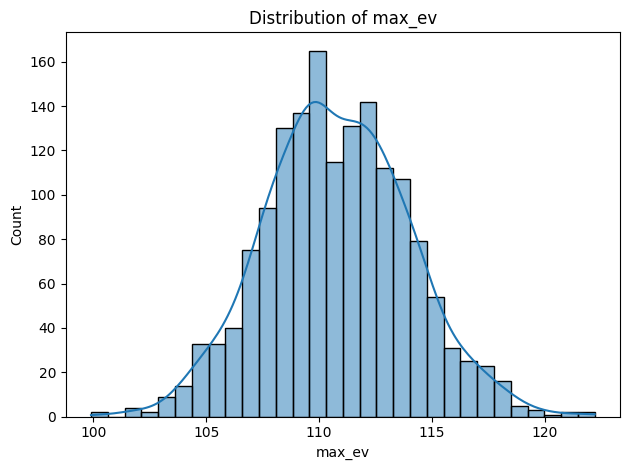

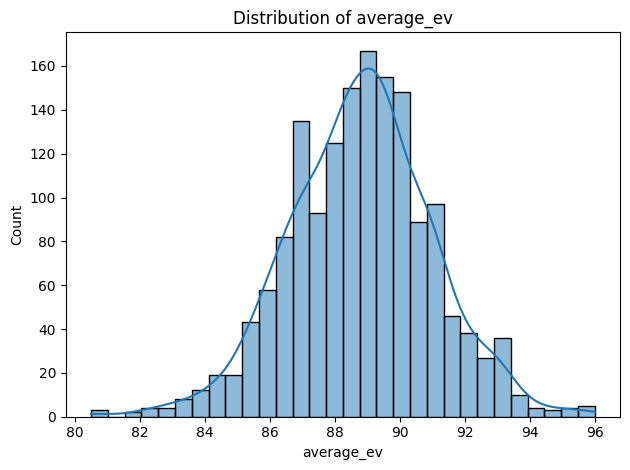

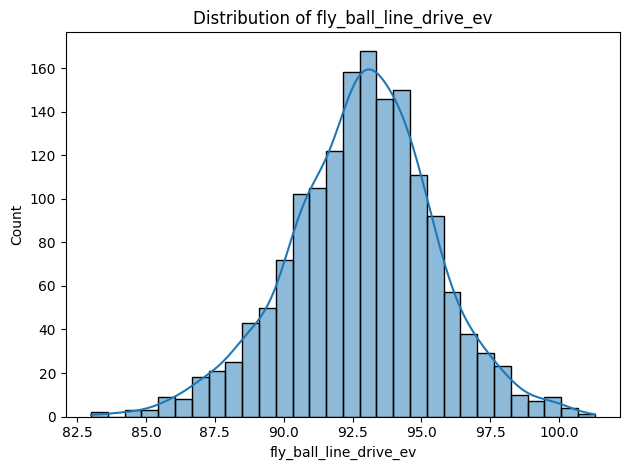

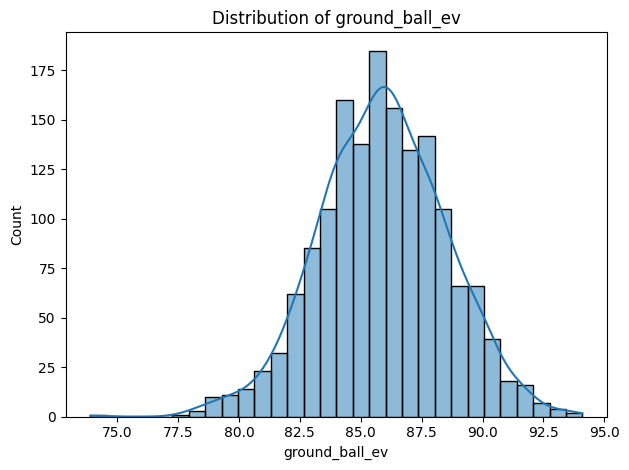

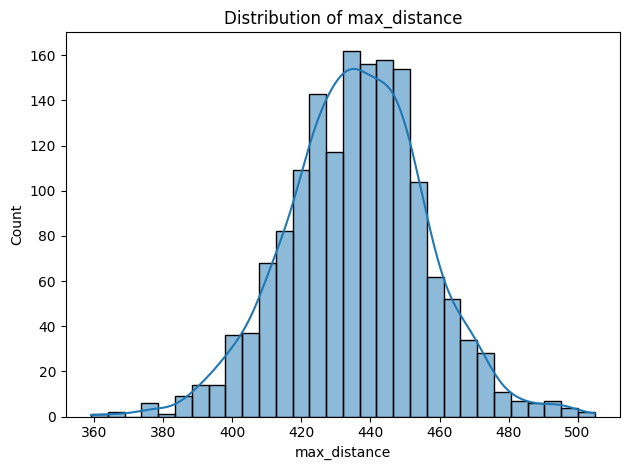

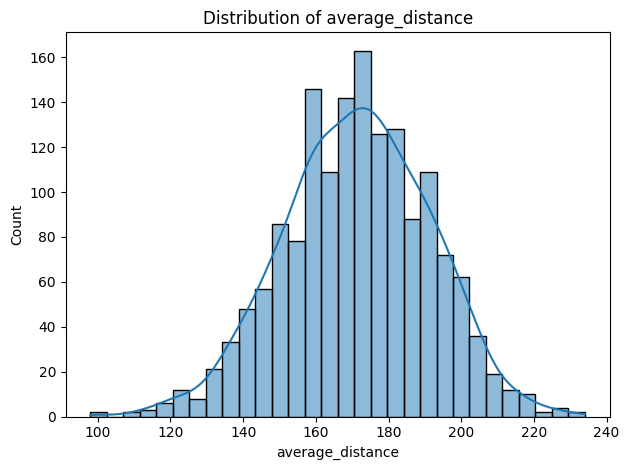

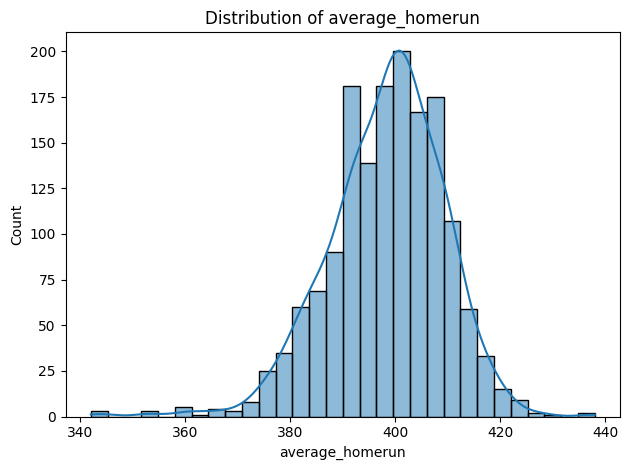

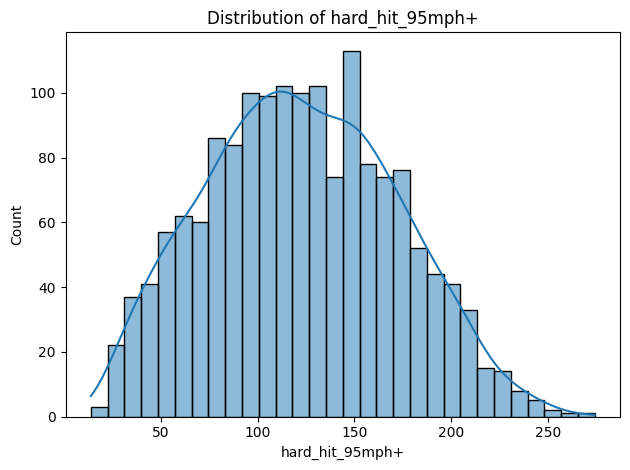

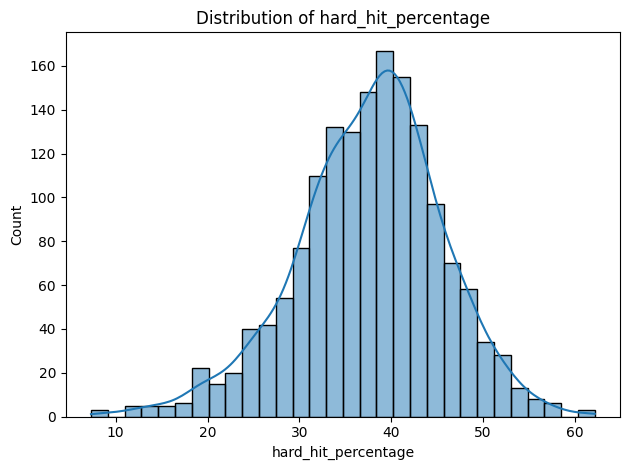

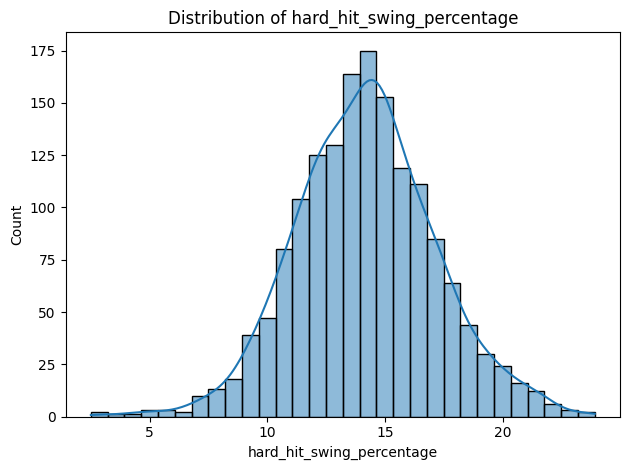

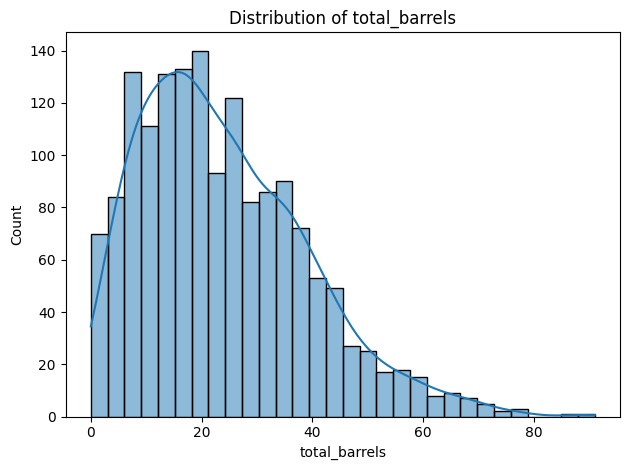

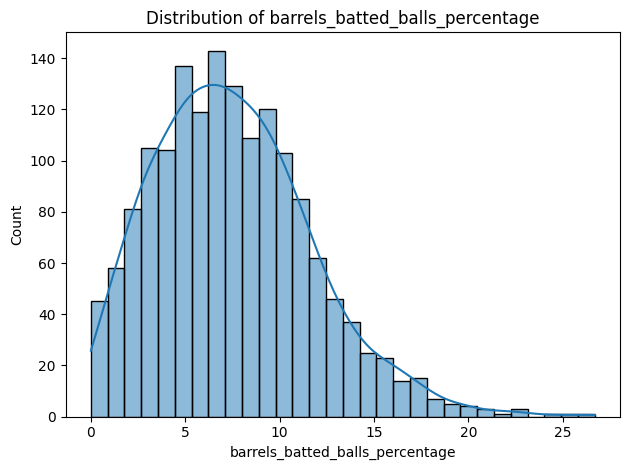

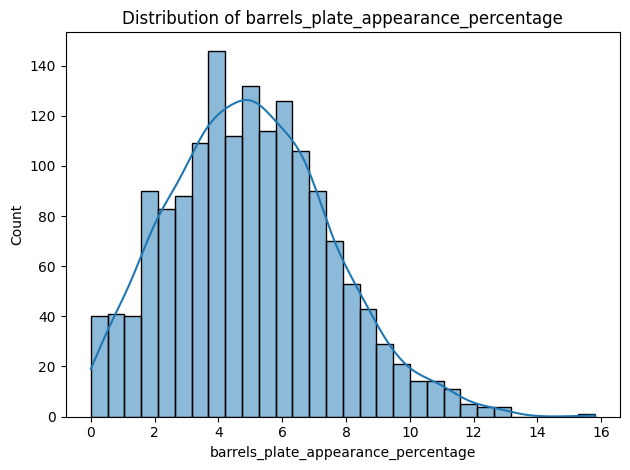

In [ ]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [ ]:
corr = df.corr(numeric_only=True)

print("\nCorrelation with hard_hit_percentage:")
corr_target = corr[target_col].sort_values(ascending=False)
print(corr_target)


Correlation with hard_hit_percentage:
hard_hit_percentage                    1.000000
average_ev                             0.922907
fly_ball_line_drive_ev                 0.902168
barrels_plate_appearance_percentage    0.796630
barrels_batted_balls_percentage        0.782118
hard_hit_swing_percentage              0.771878
max_ev                                 0.677524
total_barrels                          0.646216
max_distance                           0.597921
ground_ball_ev                         0.573011
average_homerun                        0.501228
hard_hit_95mph+                        0.449425
average_distance                       0.352412
year                                   0.261632
sweet_spot_percentage                  0.169548
launch_angle                           0.127196
batted_ball_events                    -0.103208
Name: hard_hit_percentage, dtype: float64


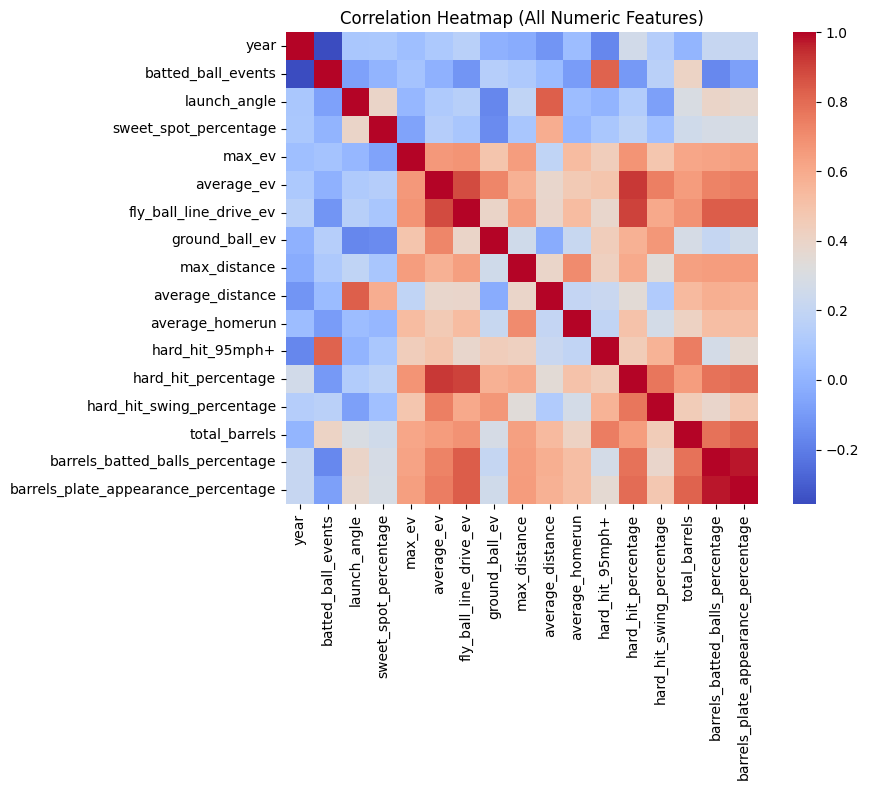

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False, fmt=".2f", square=True)
plt.title("Correlation Heatmap (All Numeric Features)")
plt.tight_layout()
plt.show()

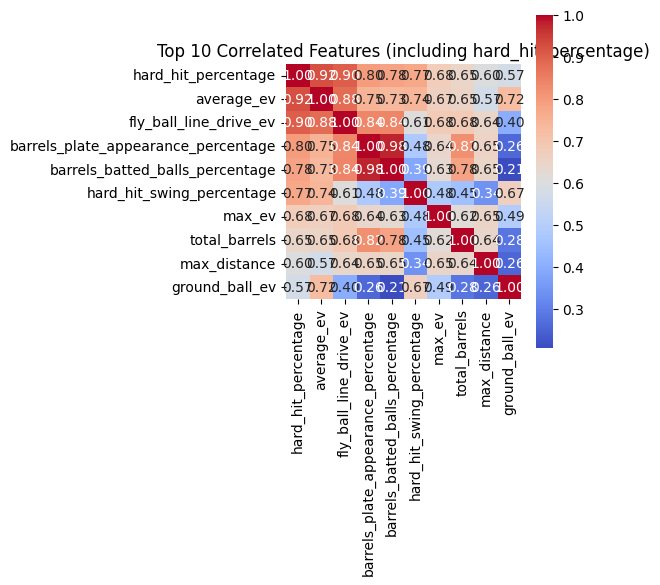

In [ ]:
top_k = 10  # number of top features to show (including target)
top_features = corr_target.index[:top_k]

plt.figure(figsize=(6, 6))
sns.heatmap(
    corr.loc[top_features, top_features],
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True
)
plt.title(f"Top {top_k} Correlated Features (including {target_col})")
plt.tight_layout()
plt.show()

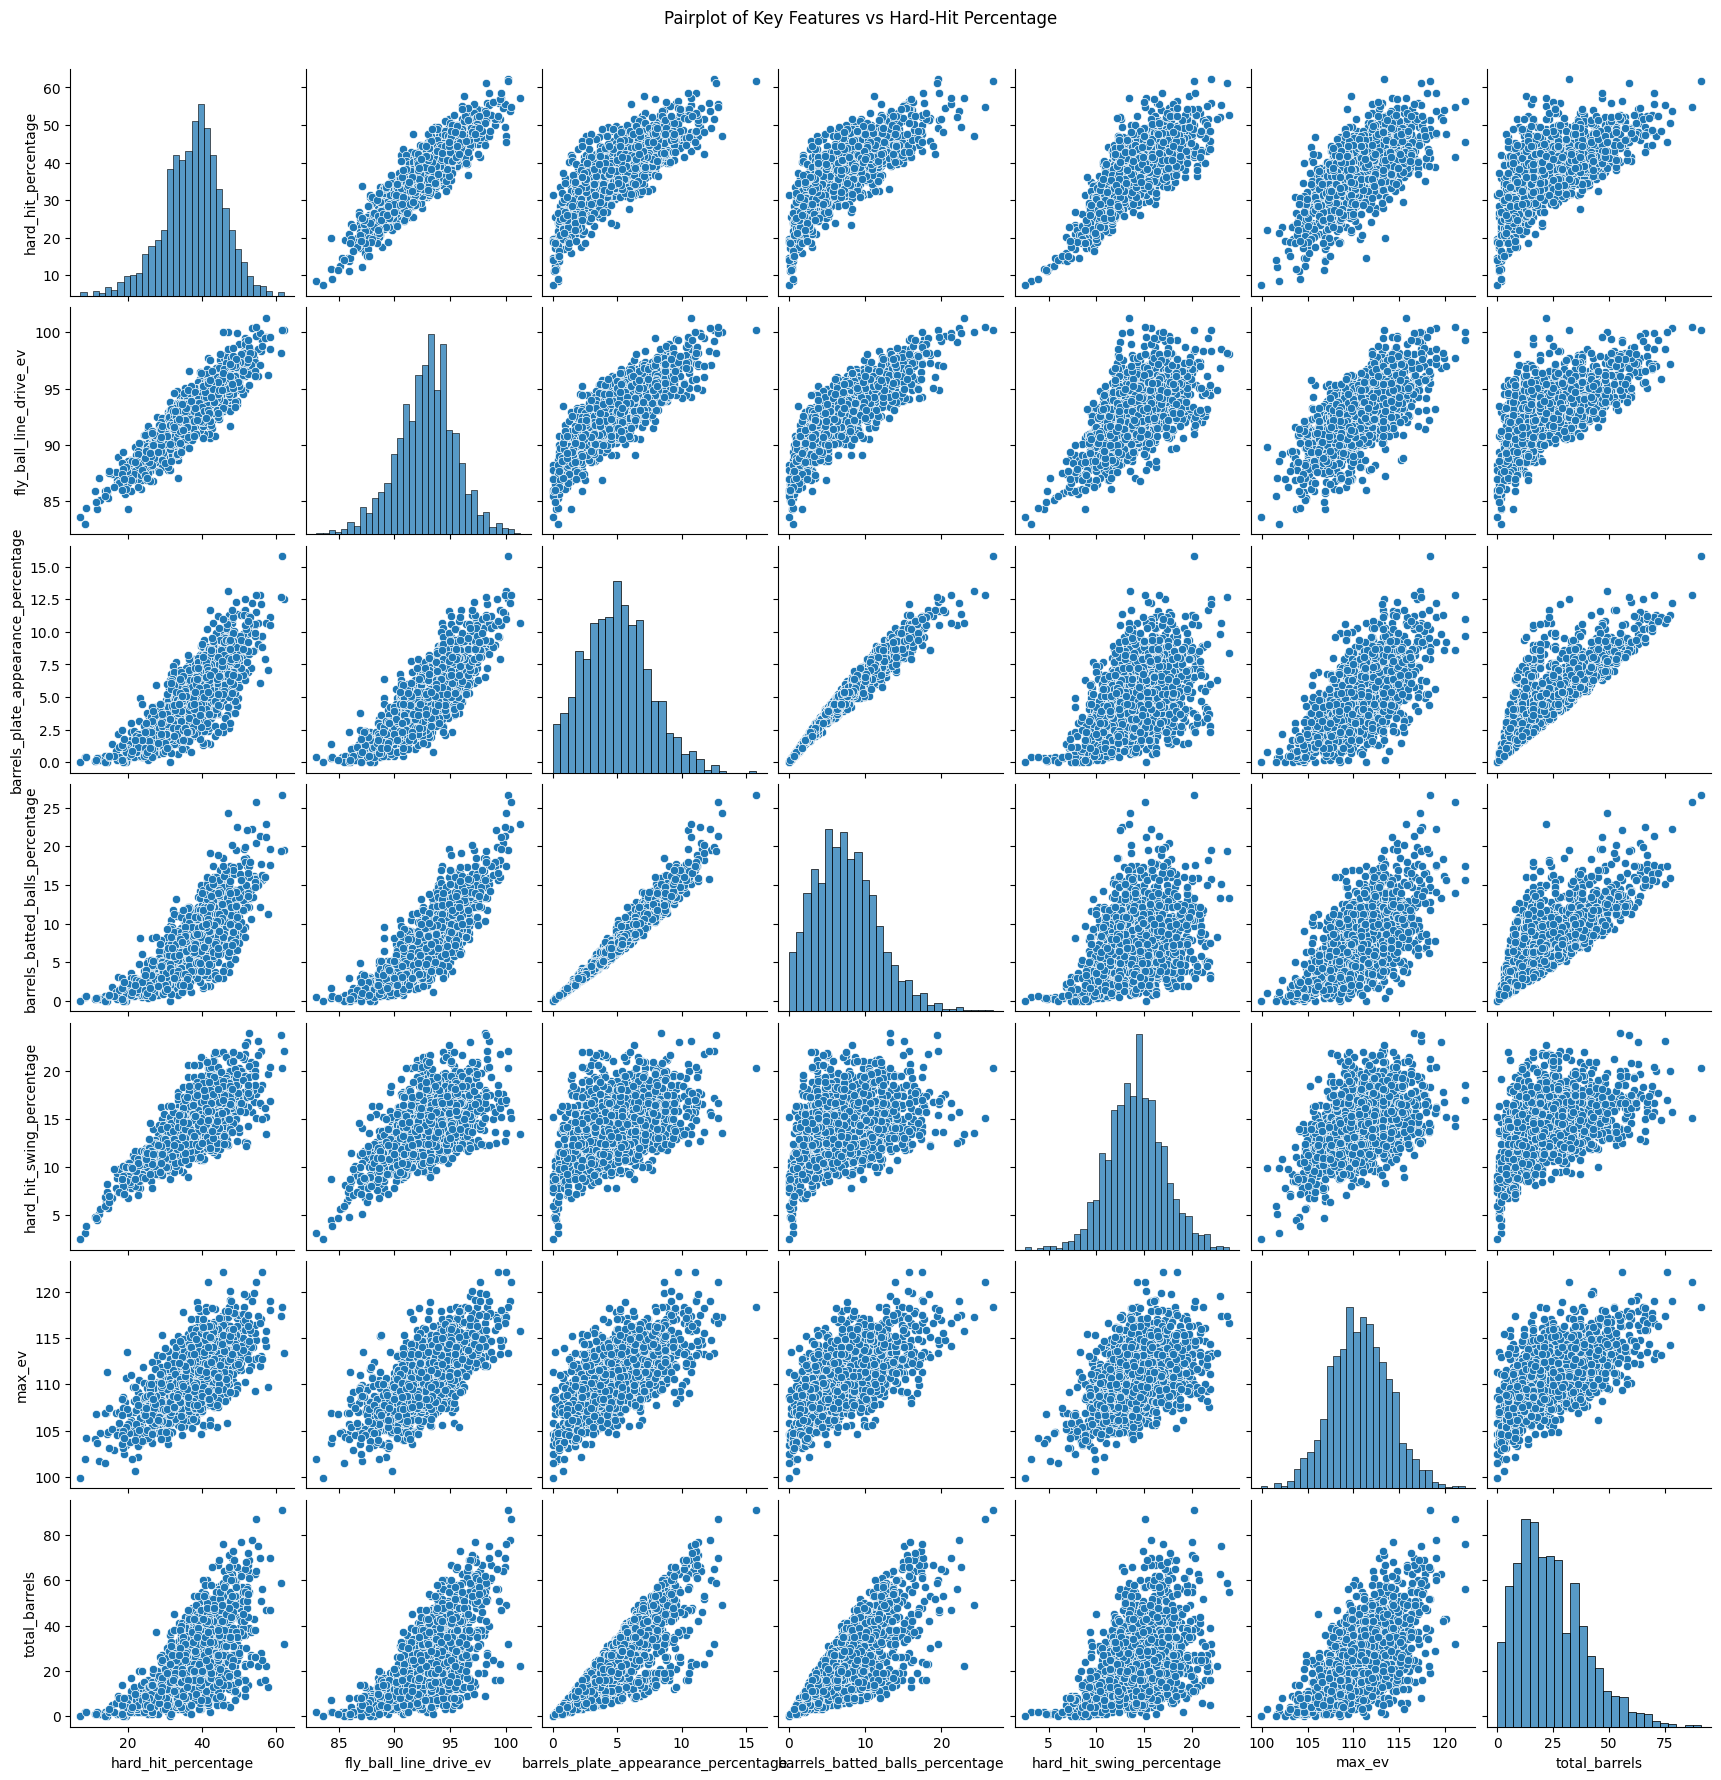

In [ ]:
subset_features = [
    target_col,
    "fly_ball_line_drive_ev",
    "barrels_plate_appearance_percentage",
    "barrels_batted_balls_percentage",
    "hard_hit_swing_percentage",
    "max_ev",
    "total_barrels"
]

subset_features = [f for f in subset_features if f in df.columns]

sns.pairplot(df[subset_features])
plt.suptitle("Pairplot of Key Features vs Hard-Hit Percentage", y=1.02)
plt.show()

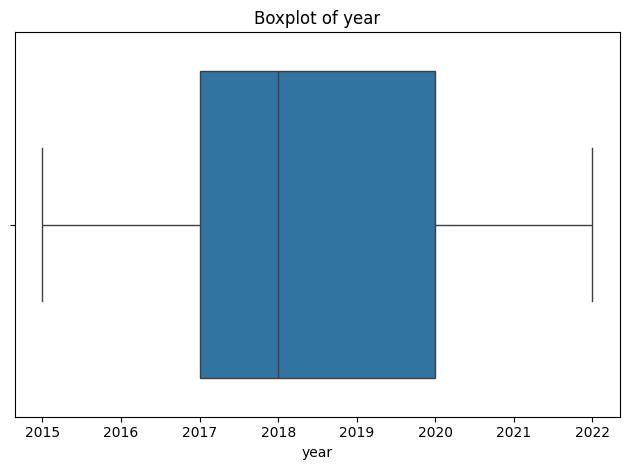

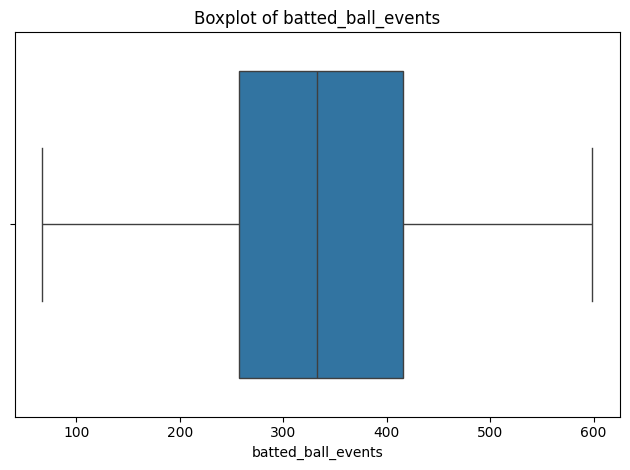

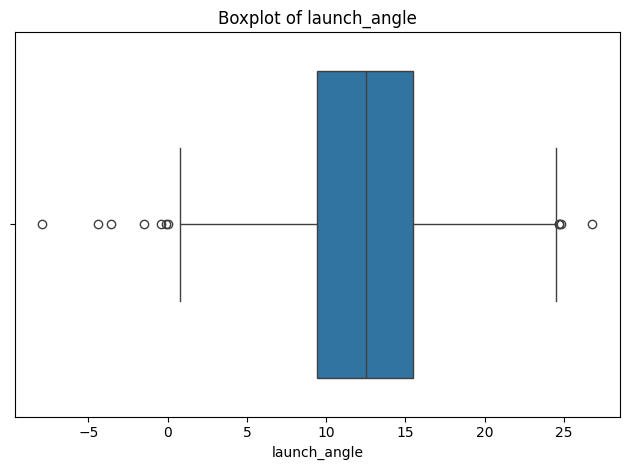

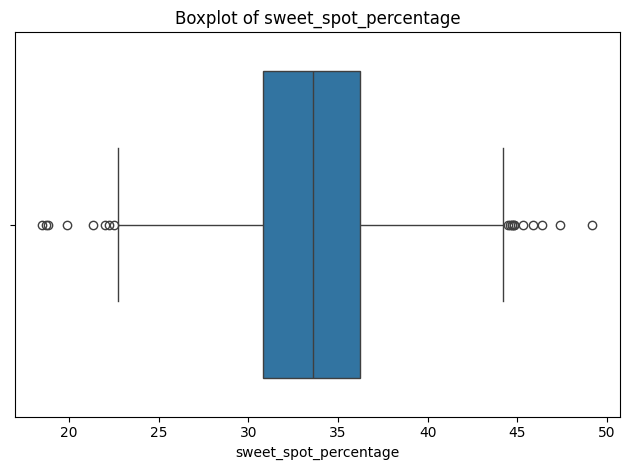

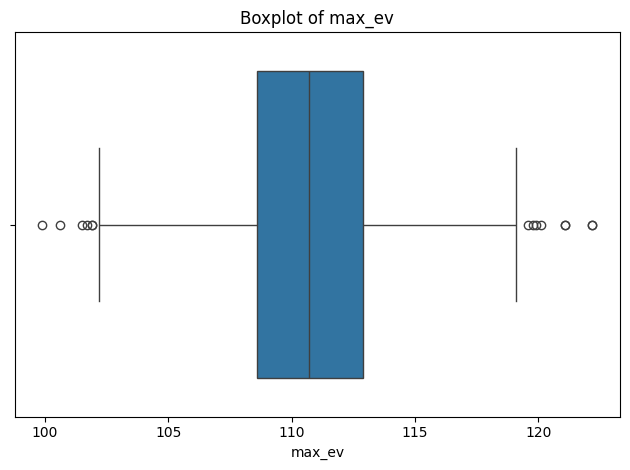

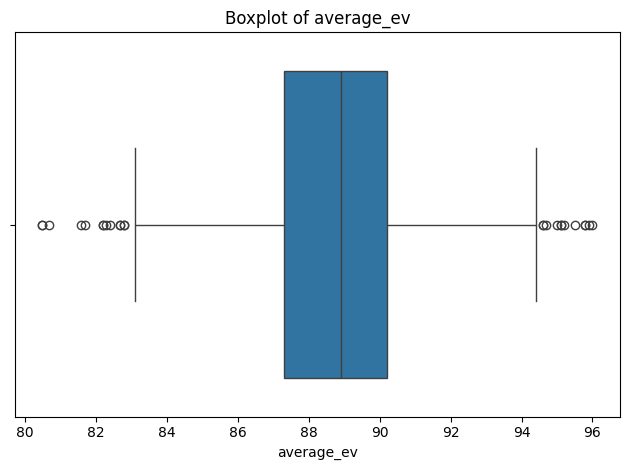

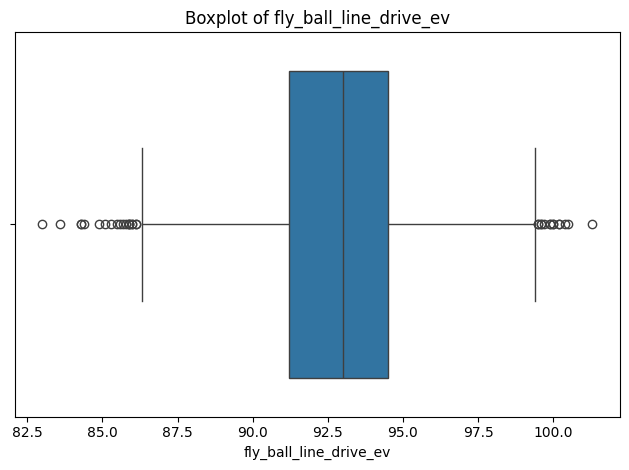

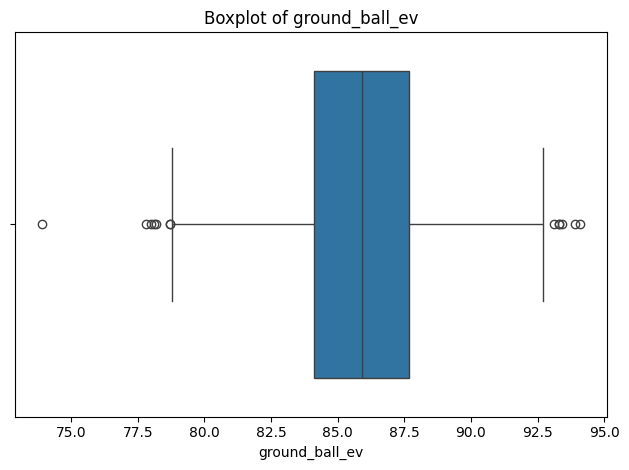

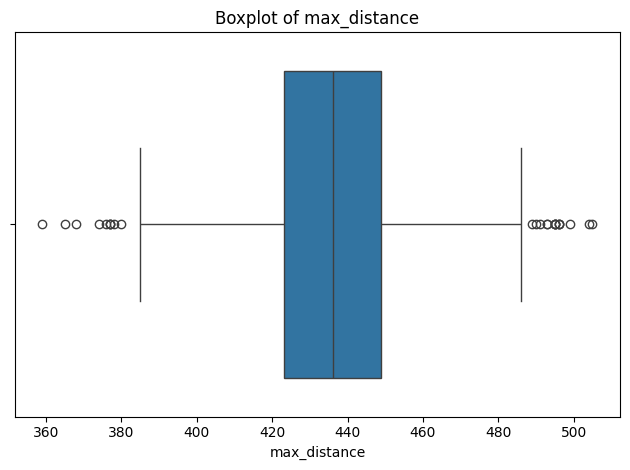

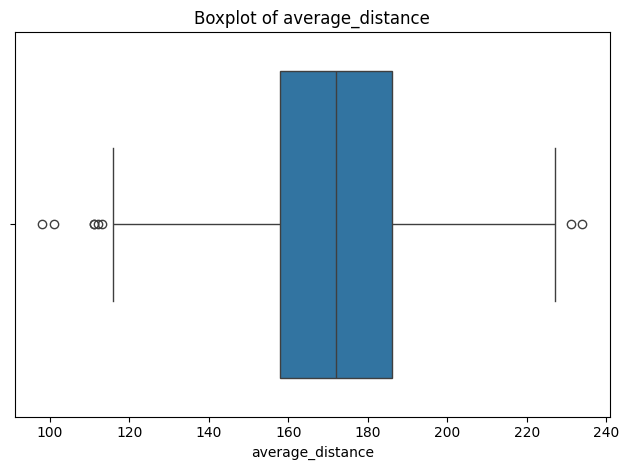

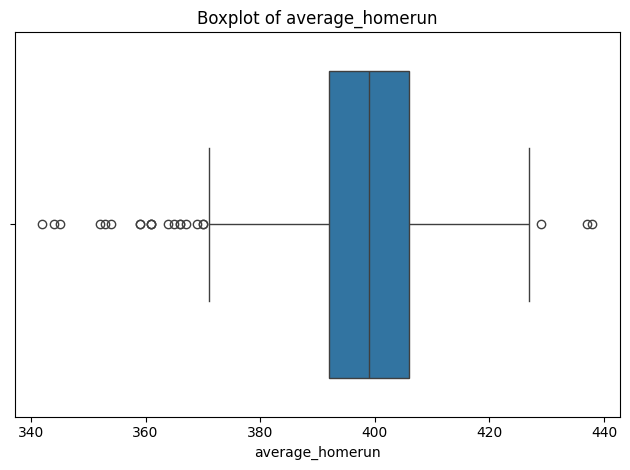

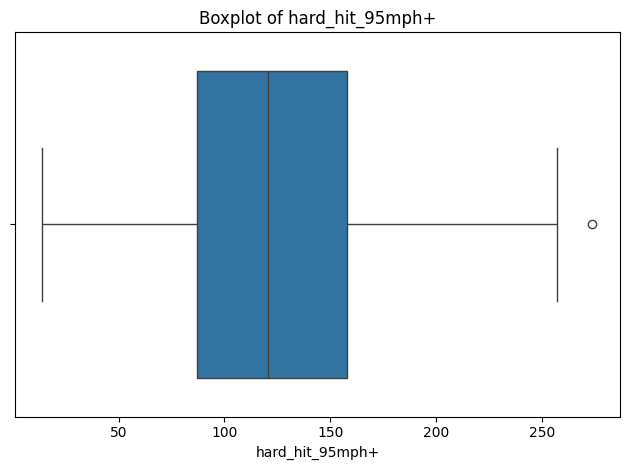

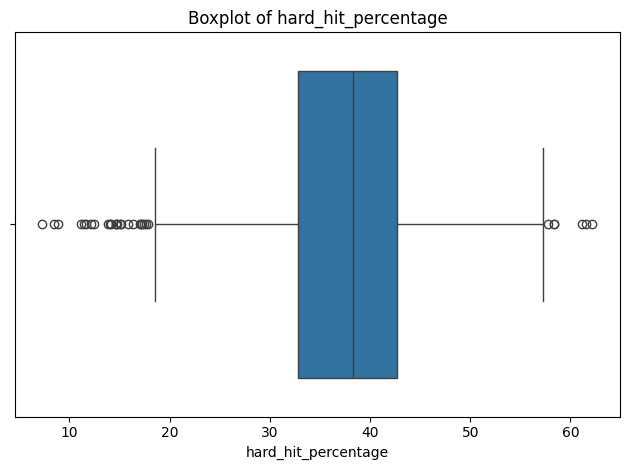

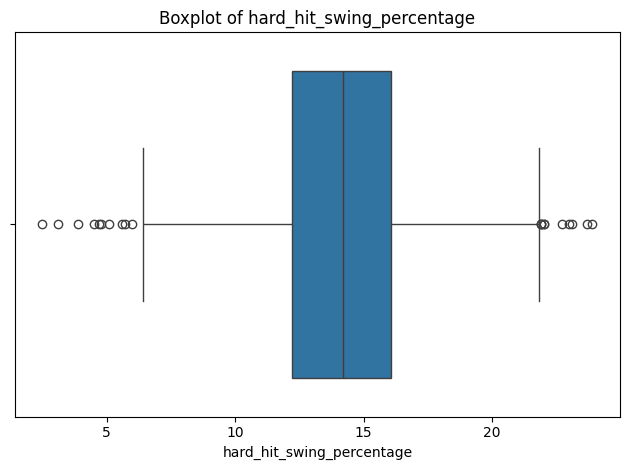

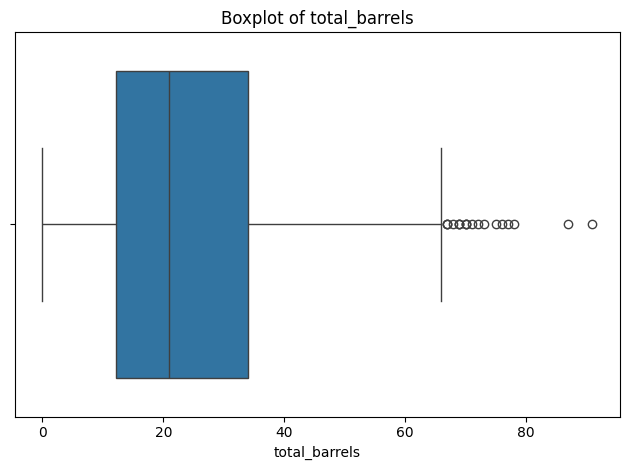

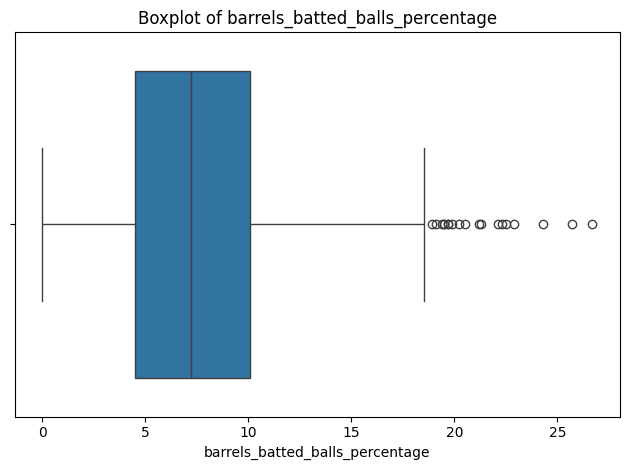

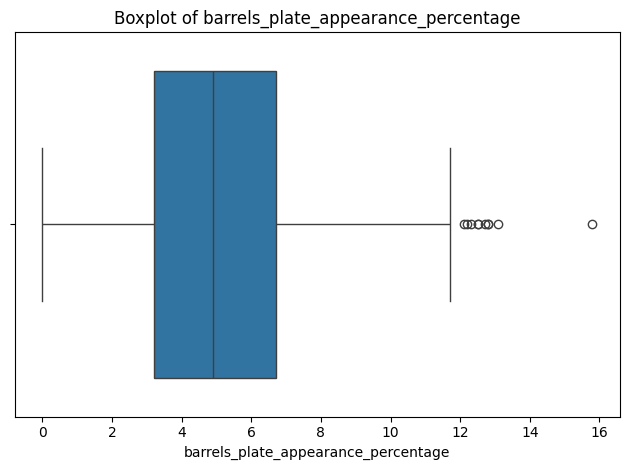

In [ ]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


Year-wise summary of hard_hit_percentage:


,count,mean,std,min,max
year,,,,,
2015,197,34.390863,8.244758,8.9,53.3
2016,196,35.792347,8.002480,11.5,52.4
2017,195,35.064615,7.568568,11.2,54.7
2018,206,37.391262,7.368100,8.5,54.1
2019,201,38.306468,7.718044,7.3,58.4
2020,208,39.206250,7.907412,14.6,62.2
2021,183,40.220219,7.697279,14.1,58.4
2022,200,40.338500,7.095810,20.1,61.6


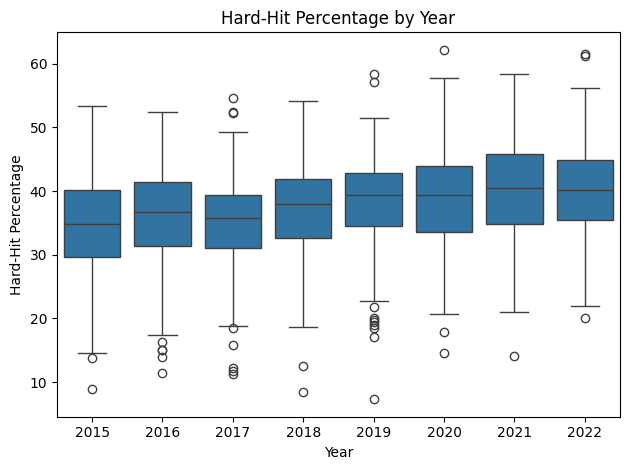

In [ ]:
if "year" in df.columns:
    print("\nYear-wise summary of hard_hit_percentage:")
    year_summary = df.groupby("year")[target_col].agg(["count", "mean", "std", "min", "max"])
    display(year_summary)

    plt.figure()
    sns.boxplot(x="year", y=target_col, data=df)
    plt.title("Hard-Hit Percentage by Year")
    plt.xlabel("Year")
    plt.ylabel("Hard-Hit Percentage")
    plt.tight_layout()
    plt.show()